# Fruit Vegetables Classification

In [2]:
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
import warnings
warnings.filterwarnings("ignore")

## Exploraty Data Analysis and Data Preprocessing

In [4]:
fruit_folders = [
    'apple', 'banaana', 'grapes', 'kiwi', 'lemon', 'mango', 
    'orange', 'pear', 'pineaplle', 'pomegranate', 'watermelon']
vegetable_folders = [
    'beetroot', 'bell pepper', 'cabbage', 'capiscum', 'carrot', 
    'cauliflower', 'chili pepper', 'corn', 'cucumber', 'eggplant', 
    'garlic', 'ginger', 'jalepeno', 'lettuce', 'onion', 'paprika', 
    'peas', 'patato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 
    'sweetpatato', 'tomato', 'turnip'
]

In [5]:
img_path="Fruit-Vegetables-Dataset/train/"

In [6]:
img_list = []
label_list = []
for category in os.listdir(img_path):
    category_path = os.path.join(img_path, category)
    
    if os.path.isdir(category_path):
        if category in fruit_folders:
            label = "Fruit"
        elif category in vegetable_folders:
            label = "Vegetables"
        else:
            continue
            
        for img_file in os.listdir(category_path):
            img_list.append(os.path.join(category_path, img_file))
            label_list.append(label)

In [7]:
df=pd.DataFrame({"img":img_list,"label":label_list})

In [8]:
df.label.value_counts()

label
Vegetables    1874
Fruit          745
Name: count, dtype: int64

In [9]:
d=({"Fruit":1,"Vegetables":0})
df["label_encoded"]=df["label"].map(d)

In [10]:
df

,img,label,label_encoded
0,Fruit-Vegetables-Dataset/train/apple\Image_1.jpg,Fruit,1
1,Fruit-Vegetables-Dataset/train/apple\Image_10.jpg,Fruit,1
2,Fruit-Vegetables-Dataset/train/apple\Image_16.jpg,Fruit,1
3,Fruit-Vegetables-Dataset/train/apple\Image_17.jpg,Fruit,1
4,Fruit-Vegetables-Dataset/train/apple\Image_18.jpg,Fruit,1
...,...,...,...
2614,Fruit-Vegetables-Dataset/train/watermelon\Imag...,Fruit,1
2615,Fruit-Vegetables-Dataset/train/watermelon\Imag...,Fruit,1
2616,Fruit-Vegetables-Dataset/train/watermelon\Imag...,Fruit,1
2617,Fruit-Vegetables-Dataset/train/watermelon\Imag...,Fruit,1


In [11]:
x=[]
valid_indices=[]
for idx, img_path in enumerate(df["img"]):
    img = cv2.imread(str(img_path))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img=cv2.resize(img,(128,128))
        img=img/255.0 #normalize ediyoruz
        x.append(img)
        valid_indices.append(idx)

In [12]:
x = np.array(x)
y = np.array(df["label_encoded"].iloc[valid_indices])

# Model Training and Testing

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.20,stratify=y)

In [14]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=20,batch_size=64,verbose=1)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6878 - loss: 0.6707 - val_accuracy: 0.7156 - val_loss: 0.5732
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7150 - loss: 0.5712 - val_accuracy: 0.7156 - val_loss: 0.5824
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7155 - loss: 0.5592 - val_accuracy: 0.7195 - val_loss: 0.5510
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7103 - loss: 0.5231 - val_accuracy: 0.7156 - val_loss: 0.5232
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7232 - loss: 0.5071 - val_accuracy: 0.7672 - val_loss: 0.5005
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7527 - loss: 0.4766 - val_accuracy: 0.7519 - val_loss: 0.5124
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7804 - loss: 0.4401 - val_accuracy: 0.7844 - val_loss: 0.4642
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.7995 - loss: 0.4350 - val_accuracy: 0.8168 - val_loss:

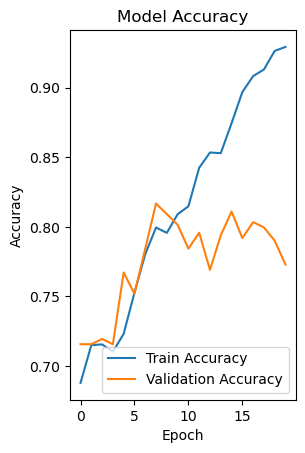

In [16]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step


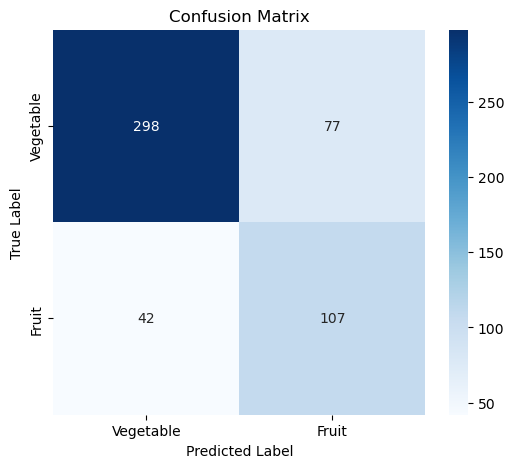

In [17]:
predictions = model.predict(x_test)

y_pred = (predictions > 0.5).astype(int)

class_names = ['Vegetable', 'Fruit']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [18]:
model.save("fruit_vegetable_model.keras")

# Transfer Learning

In [23]:
from tensorflow.keras.applications import MobileNetV2

dataset_dir = 'Fruit-Vegetables-Dataset'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'validation')

img_shape = (128, 128, 3)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(128, 128),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=img_shape
)
base_model.trainable = False  
if num_classes == 2:
    output_layer = layers.Dense(1, activation='sigmoid')
    loss_function = 'binary_crossentropy'
else:
    output_layer = layers.Dense(num_classes, activation='softmax')
    loss_function = 'sparse_categorical_crossentropy'

model_fruit_tl = models.Sequential([
    layers.Rescaling(1./255, input_shape=img_shape),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  
    output_layer
])

model_fruit_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=['accuracy']
)



Found 3115 files belonging to 36 classes.
Found 351 files belonging to 36 classes.


In [22]:
history_fruit_tl = model_fruit_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 93s 502ms/step - accuracy: 0.4077 - loss: 2.2526 - val_accuracy: 0.8234 - val_loss: 0.6180
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 358ms/step - accuracy: 0.7088 - loss: 0.9647 - val_accuracy: 0.9259 - val_loss: 0.3153
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 386ms/step - accuracy: 0.8035 - loss: 0.6377 - val_accuracy: 0.9316 - val_loss: 0.2625
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 393ms/step - accuracy: 0.8526 - loss: 0.4763 - val_accuracy: 0.9487 - val_loss: 0.1933
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 404ms/step - accuracy: 0.8831 - loss: 0.3650 - val_accuracy: 0.9573 - val_loss: 0.1520
